# PDAF v3.0 — Trace Annotation Visualizer

Visualizes the HPOP / PDAF pipeline output for a WebLINX trace:

1. **Phase timeline** — the CPA-instance sequence coloured by cognitive phase (Layer A).
2. **CPA dependency DAG** — the local partial order; nodes are CPA instances on phase lanes, edges are the 8 typed dependency labels. `INCOMPARABLE` (dashed) marks order-free pairs — the parallelism HPOP exploits.
3. **Dependency-label distribution** — with the 15% `ADJACENT_ONLY` monitor (Step 4).
4. **Confidence tiers** — HIGH / MEDIUM / ABSTAIN per CPA and edge.

It auto-loads real outputs from `data/annotated/weblinx/*.skills.jsonl` + `*.local_orders.jsonl` if present, otherwise renders a built-in demo (Report 3's T5 `verify_fact`).

In [1]:
%matplotlib inline
import json, os, glob
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D

# repo root = parent of notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd())=='notebooks' else os.getcwd()
ANNOT_PREFIX = os.path.join(ROOT, 'data', 'annotated', 'weblinx', 'valid')

def _read_jsonl(p):
    out=[]
    with open(p, encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if line: out.append(json.loads(line))
    return out
print('repo root:', ROOT)

Matplotlib is building the font cache; this may take a moment.


repo root: /Users/dongqing/Desktop/hpop


In [2]:
# ---- built-in DEMO (Report 3, T5 verify_fact) used when no real annotations exist ----
def demo_record_and_edges():
    cpas = [
        ('FORMULATE_GOAL','PLAN',0.90), ('SEARCH_SOURCE','RETRIEVE',0.88),
        ('READ_SOURCE','INSPECT',0.85), ('EXTRACT_EVIDENCE','EXTRACT',0.92),
        ('NAVIGATE_PAGE','RETRIEVE',0.83), ('READ_SOURCE','INSPECT',0.80),
        ('READ_SOURCE','INSPECT',0.60), ('READ_SOURCE','INSPECT',0.45),
        ('EXTRACT_EVIDENCE','EXTRACT',0.90), ('VERIFY_CLAIM','VERIFY',0.88),
        ('WRITE_RESPONSE','WRITE',0.91),
    ]
    rec = {'trace_id':'T5','skill_id':'S005','skill_name':'verify_fact','skill_is_new':False,'skill_confidence':0.86,
           'cpa_instances':[{'cpa_instance_id':'T5-CPA%d'%(i+1),'cpa':c,'phase':p,'confidence':cf,
                             'turn_start':i,'turn_end':i,'event_indices':[i],'artifact_id':''}
                            for i,(c,p,cf) in enumerate(cpas)],
           'global_cpa_sequence':[c for c,_,_ in cpas],'global_phase_sequence':[p for _,p,_ in cpas]}
    E = [(0,1,'ELABORATES',0.85),(1,2,'STATE_CHANGE',0.88),(2,3,'DATA_FLOW',0.9),(3,4,'PRECONDITION',0.8),
         (4,5,'STATE_CHANGE',0.82),(5,6,'INCOMPARABLE',0.78),(6,7,'INCOMPARABLE',0.7),(5,7,'INCOMPARABLE',0.7),
         (7,8,'DATA_FLOW',0.86),(3,9,'VERIFY_OF',0.9),(8,9,'VERIFY_OF',0.9),(9,10,'DATA_FLOW',0.92),
         (1,4,'PRECONDITION',0.6),(2,5,'STATE_CHANGE',0.75),(0,9,'ELABORATES',0.65),(4,8,'STATE_CHANGE',0.55)]
    cid = lambda i: 'T5-CPA%d'%(i+1)
    edges=[{'edge_id':'T5-E%d'%(n+1),'trace_id':'T5','skill_name':'verify_fact',
            'source_cpa_id':cid(s),'target_cpa_id':cid(t),'source_cpa':cpas[s][0],'target_cpa':cpas[t][0],
            'label':lab,'confidence':cf,'rationale':'','artifact_transferred':''} for n,(s,t,lab,cf) in enumerate(E)]
    return rec, edges

def load_data():
    sk = ANNOT_PREFIX + '.skills.jsonl'; lo = ANNOT_PREFIX + '.local_orders.jsonl'
    if os.path.exists(sk) and os.path.exists(lo):
        recs = _read_jsonl(sk); alle = _read_jsonl(lo)
        by_id = {r['trace_id']: r for r in recs}
        edges_by = {}
        for e in alle: edges_by.setdefault(e['trace_id'], []).append(e)
        print('Loaded REAL annotations: %d traces, %d edges' % (len(recs), len(alle)))
        return by_id, edges_by, False
    rec, edges = demo_record_and_edges()
    print('No real annotations found -> using built-in DEMO (T5 verify_fact).')
    print('Generate real ones with:  PYTHONPATH=src .venv/bin/python -m hpop.annotate.run \\')
    print('    --input data/interim/weblinx/valid.normalized.jsonl --output data/annotated/weblinx/valid --limit 5')
    return {rec['trace_id']: rec}, {rec['trace_id']: edges}, True

BY_ID, EDGES_BY, IS_DEMO = load_data()
TRACE_ID = sorted(BY_ID)[0]   # <-- change to visualize a different trace
REC = BY_ID[TRACE_ID]; EDGES = EDGES_BY.get(TRACE_ID, [])
print('Visualizing trace:', TRACE_ID, '| skill:', REC['skill_name'], '| CPAs:', len(REC['cpa_instances']), '| edges:', len(EDGES))

No real annotations found -> using built-in DEMO (T5 verify_fact).
Generate real ones with:  PYTHONPATH=src .venv/bin/python -m hpop.annotate.run \
    --input data/interim/weblinx/valid.normalized.jsonl --output data/annotated/weblinx/valid --limit 5
Visualizing trace: T5 | skill: verify_fact | CPAs: 11 | edges: 16


In [3]:
# ---- shared style maps ----
PHASES = ['PLAN','RETRIEVE','INSPECT','EXTRACT','VERIFY','WRITE','SYNTHESIZE','REPAIR','HANDOFF']
PHASE_COLORS = dict(zip(PHASES, plt.get_cmap('tab10').colors[:9]))
LABELS = ['REPAIR_OF','VERIFY_OF','DATA_FLOW','STATE_CHANGE','PRECONDITION','ELABORATES','INCOMPARABLE','ADJACENT_ONLY']
LABEL_COLORS = dict(zip(LABELS, ['#d62728','#9467bd','#1f77b4','#2ca02c','#ff7f0e','#8c564b','#7f7f7f','#bdbdbd']))
def tier(c):
    return 'HIGH' if c>=0.8 else ('MEDIUM' if c>=0.5 else 'ABSTAIN')
TIER_COLORS = {'HIGH':'#2ca02c','MEDIUM':'#ff7f0e','ABSTAIN':'#d62728'}

## 1. Phase timeline

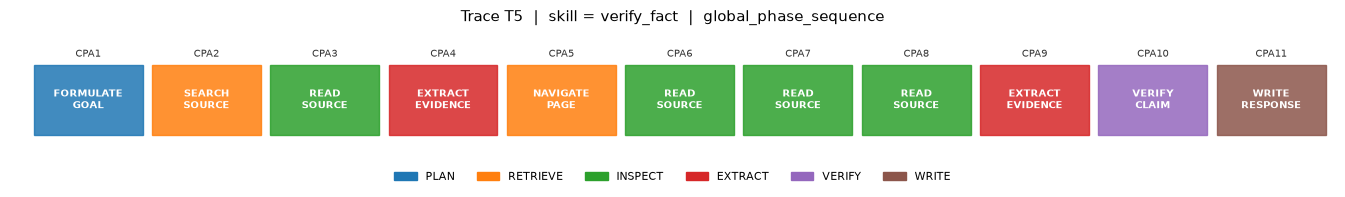

In [4]:
def plot_phase_timeline(rec):
    cpas = rec['cpa_instances']
    fig, ax = plt.subplots(figsize=(min(1.05*len(cpas)+2, 20), 2.4))
    for i,c in enumerate(cpas):
        col = PHASE_COLORS.get(c['phase'], '#999')
        ax.add_patch(plt.Rectangle((i,0),0.92,1, color=col, alpha=0.85))
        ax.text(i+0.46,0.5, c['cpa'].replace('_','\n'), ha='center', va='center', fontsize=7, color='white', weight='bold')
        ax.text(i+0.46,1.08, 'CPA%d'%(i+1), ha='center', va='bottom', fontsize=7, color='#333')
    ax.set_xlim(-0.2,len(cpas)); ax.set_ylim(-0.1,1.5); ax.axis('off')
    present=[p for p in PHASES if any(c['phase']==p for c in cpas)]
    ax.legend(handles=[Patch(color=PHASE_COLORS[p], label=p) for p in present], ncol=len(present), loc='lower center', bbox_to_anchor=(0.5,-0.45), fontsize=8, frameon=False)
    ax.set_title('Trace %s  |  skill = %s  |  global_phase_sequence' % (rec['trace_id'], rec['skill_name']), fontsize=11)
    plt.tight_layout(); plt.show()
plot_phase_timeline(REC)

## 2. CPA dependency DAG (the local partial order)
Nodes sit on phase lanes, left-to-right in sequence. Edge colour = dependency label; `INCOMPARABLE` is dashed and headless (order-free / parallel).

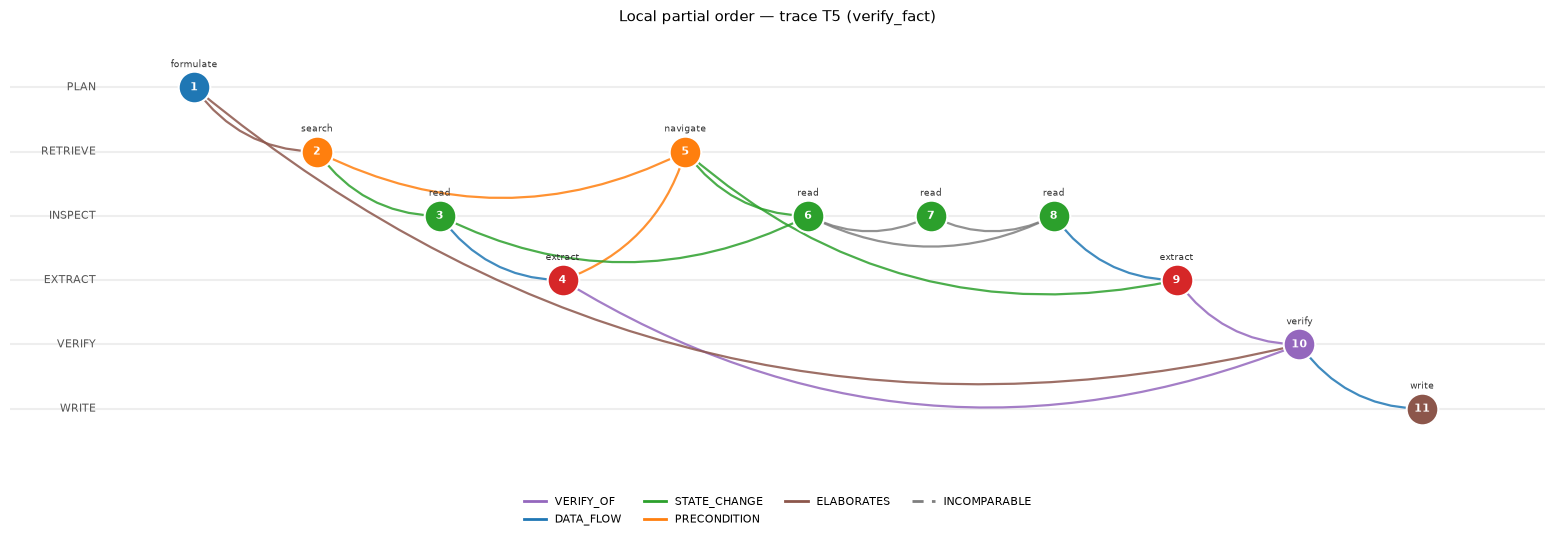

In [5]:
def plot_dag(rec, edges):
    cpas = rec['cpa_instances']
    lane = {p:i for i,p in enumerate(PHASES)}
    pos = {i: (i, -lane.get(c['phase'],0)) for i,c in enumerate(cpas)}
    idx_of = {c['cpa_instance_id']: i for i,c in enumerate(cpas)}
    fig, ax = plt.subplots(figsize=(min(1.15*len(cpas)+3, 22), 5.5))
    used_lanes = sorted({lane.get(c['phase'],0) for c in cpas})
    for ln in used_lanes:
        ax.axhline(-ln, color='#eee', zorder=0)
        ax.text(-0.8, -ln, PHASES[ln], ha='right', va='center', fontsize=8, color='#555')
    for i,c in enumerate(cpas):
        x,y = pos[i]
        ax.scatter([x],[y], s=520, color=PHASE_COLORS.get(c['phase'],'#999'), edgecolors='white', linewidths=1.5, zorder=3)
        ax.text(x,y,'%d'%(i+1), ha='center', va='center', color='white', fontsize=8, weight='bold', zorder=4)
        ax.text(x, y+0.28, c['cpa'].split('_')[0].lower(), ha='center', va='bottom', fontsize=6.5, color='#333')
    for e in edges:
        s = idx_of.get(e['source_cpa_id']); t = idx_of.get(e['target_cpa_id'])
        if s is None or t is None: continue
        lab = e['label']; col = LABEL_COLORS.get(lab,'#999')
        incomp = (lab=='INCOMPARABLE')
        style = '-' if incomp else '-|>'
        ls = (0,(4,3)) if incomp else 'solid'
        rad = 0.25 if (pos[t][0]>=pos[s][0]) else -0.25
        ax.add_patch(FancyArrowPatch(pos[s], pos[t], connectionstyle='arc3,rad=%.2f'%rad,
                     arrowstyle=style, mutation_scale=12, lw=1.6, color=col, alpha=0.85, zorder=2))
    present=[l for l in LABELS if any(e['label']==l for e in edges)]
    handles=[Line2D([0],[0], color=LABEL_COLORS[l], lw=2, ls=((0,(4,3)) if l=='INCOMPARABLE' else 'solid'), label=l) for l in present]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5,-0.06), ncol=min(len(present),4), fontsize=8, frameon=False)
    ax.set_xlim(-1.5, len(cpas)); ax.set_ylim(-(max(used_lanes)+0.8), 0.9)
    ax.axis('off'); ax.set_title('Local partial order — trace %s (%s)' % (rec['trace_id'], rec['skill_name']), fontsize=11)
    plt.tight_layout(); plt.show()
plot_dag(REC, EDGES)

## 3. Dependency-label distribution (Step 4 monitor)

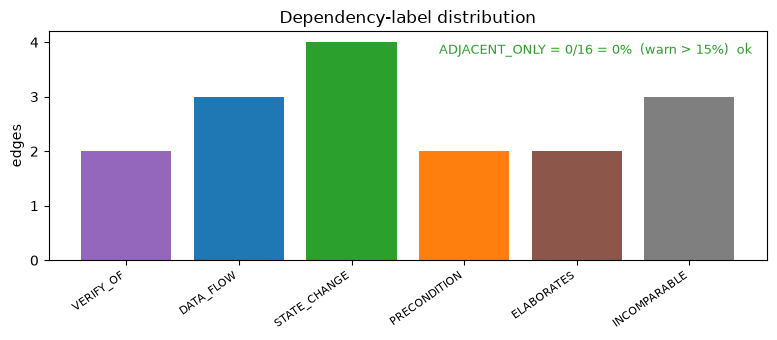

In [6]:
def plot_label_dist(edges):
    counts = {l: sum(1 for e in edges if e['label']==l) for l in LABELS}
    counts = {l:n for l,n in counts.items() if n>0}
    fig, ax = plt.subplots(figsize=(8,3.5))
    ax.bar(list(counts), list(counts.values()), color=[LABEL_COLORS[l] for l in counts])
    ax.set_ylabel('edges'); ax.set_title('Dependency-label distribution'); plt.xticks(rotation=35, ha='right', fontsize=8)
    n=len(edges); adj=counts.get('ADJACENT_ONLY',0); frac = adj/n if n else 0
    ax.annotate('ADJACENT_ONLY = %d/%d = %.0f%%  (warn > 15%%)  %s' % (adj,n,100*frac, 'WARN' if frac>0.15 else 'ok'),
                xy=(0.98,0.95), xycoords='axes fraction', ha='right', va='top', fontsize=9,
                color=('#d62728' if frac>0.15 else '#2ca02c'))
    plt.tight_layout(); plt.show()
plot_label_dist(EDGES)

## 4. Confidence tiers (HIGH / MEDIUM / ABSTAIN)

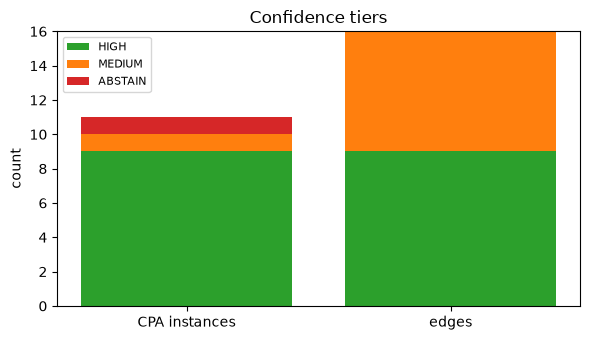

CPA tiers : {'HIGH': 9, 'MEDIUM': 1, 'ABSTAIN': 1}
Edge tiers: {'HIGH': 9, 'MEDIUM': 7, 'ABSTAIN': 0}


In [7]:
def plot_confidence(rec, edges):
    cats = ['HIGH','MEDIUM','ABSTAIN']
    cpa_t = [tier(c['confidence']) for c in rec['cpa_instances']]
    edge_t = [tier(e['confidence']) for e in edges]
    cpa_c = [cpa_t.count(k) for k in cats]; edge_c = [edge_t.count(k) for k in cats]
    fig, ax = plt.subplots(figsize=(6,3.5))
    import numpy as np; x=np.arange(2); bottom=np.zeros(2)
    for k,cc in zip(cats,[ (cpa_c[i],edge_c[i]) for i in range(3)]):
        ax.bar(x, cc, bottom=bottom, color=TIER_COLORS[k], label=k); bottom=bottom+np.array(cc)
    ax.set_xticks(x); ax.set_xticklabels(['CPA instances','edges']); ax.set_ylabel('count')
    ax.set_title('Confidence tiers'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print('CPA tiers :', dict(zip(cats,cpa_c)))
    print('Edge tiers:', dict(zip(cats,edge_c)))
plot_confidence(REC, EDGES)

## 5. Parallelism summary
`INCOMPARABLE` pairs can execute concurrently — this is the speed-up the recovered DAG buys at inference time.

In [8]:
inc = [(e['source_cpa'], e['target_cpa']) for e in EDGES if e['label']=='INCOMPARABLE']
print('INCOMPARABLE (order-free / parallelisable) CPA pairs:', len(inc))
for a,b in inc: print('   %s  ||  %s' % (a,b))
print()
print('To point this notebook at real data, run the annotator (writes data/annotated/weblinx/valid.*.jsonl), then re-run all cells.')

INCOMPARABLE (order-free / parallelisable) CPA pairs: 3
   READ_SOURCE  ||  READ_SOURCE
   READ_SOURCE  ||  READ_SOURCE
   READ_SOURCE  ||  READ_SOURCE

To point this notebook at real data, run the annotator (writes data/annotated/weblinx/valid.*.jsonl), then re-run all cells.
